# Silver Layer EDA
This notebook performs exploratory data analysis on the sanitized Silver layer datasets.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Silver Data

In [8]:
silver_path = '../data/silver/'
df_trans = pd.read_parquet(os.path.join(silver_path, 'fact_transactions.parquet'))
df_outlets = pd.read_parquet(os.path.join(silver_path, 'dim_outlets.parquet'))

print(f"Transactions loaded: {df_trans.shape}")
print(f"Outlets loaded: {df_outlets.shape}")

Transactions loaded: (2371697, 7)
Outlets loaded: (19960, 6)


## 2. Summary Measures
Detailed statistical summary for numerical columns.

In [9]:
summary = df_trans[['Volume_Liters', 'Total_Bill_Value']].describe()
display(summary)

print("\nSkewness:")
print(df_trans[['Volume_Liters', 'Total_Bill_Value']].skew())

,Volume_Liters,Total_Bill_Value
count,2.371697e+06,2.371697e+06
mean,5.261457e+01,1.378824e+04
std,9.547778e+01,1.644715e+04
min,-9.564408e+02,-1.411536e+05
25%,1.018259e+01,3.526779e+03
50%,2.315334e+01,8.058837e+03
75%,5.442028e+01,1.629049e+04
max,9.438578e+03,1.528457e+05



Skewness:
Volume_Liters       4.954121
Total_Bill_Value    2.525186
dtype: float64


## 3. Outlier Analysis
Visualizing outliers via Boxplots.

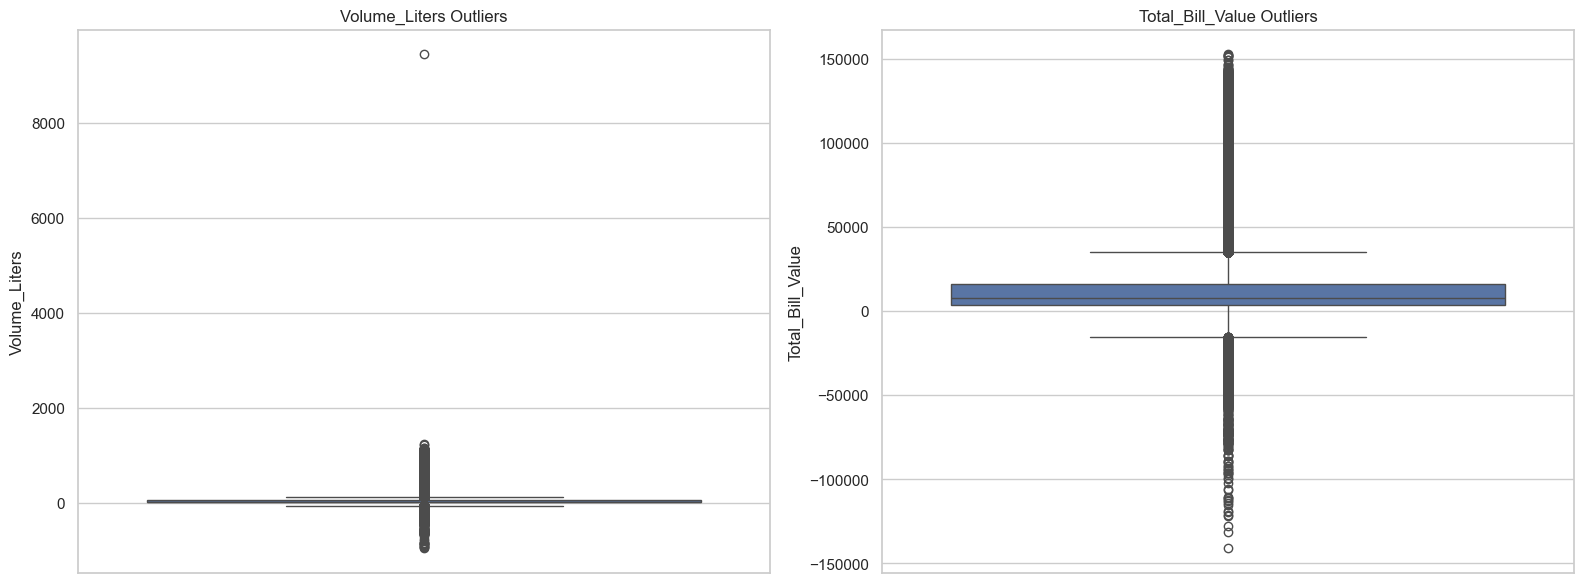

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_trans, y='Volume_Liters', ax=ax[0])
ax[0].set_title('Volume_Liters Outliers')

sns.boxplot(data=df_trans, y='Total_Bill_Value', ax=ax[1])
ax[1].set_title('Total_Bill_Value Outliers')

plt.tight_layout()
plt.show()

## 4. Aggregate Time-Series Trends
Visualizing how Volume and Amount shift over time across the whole dataset.

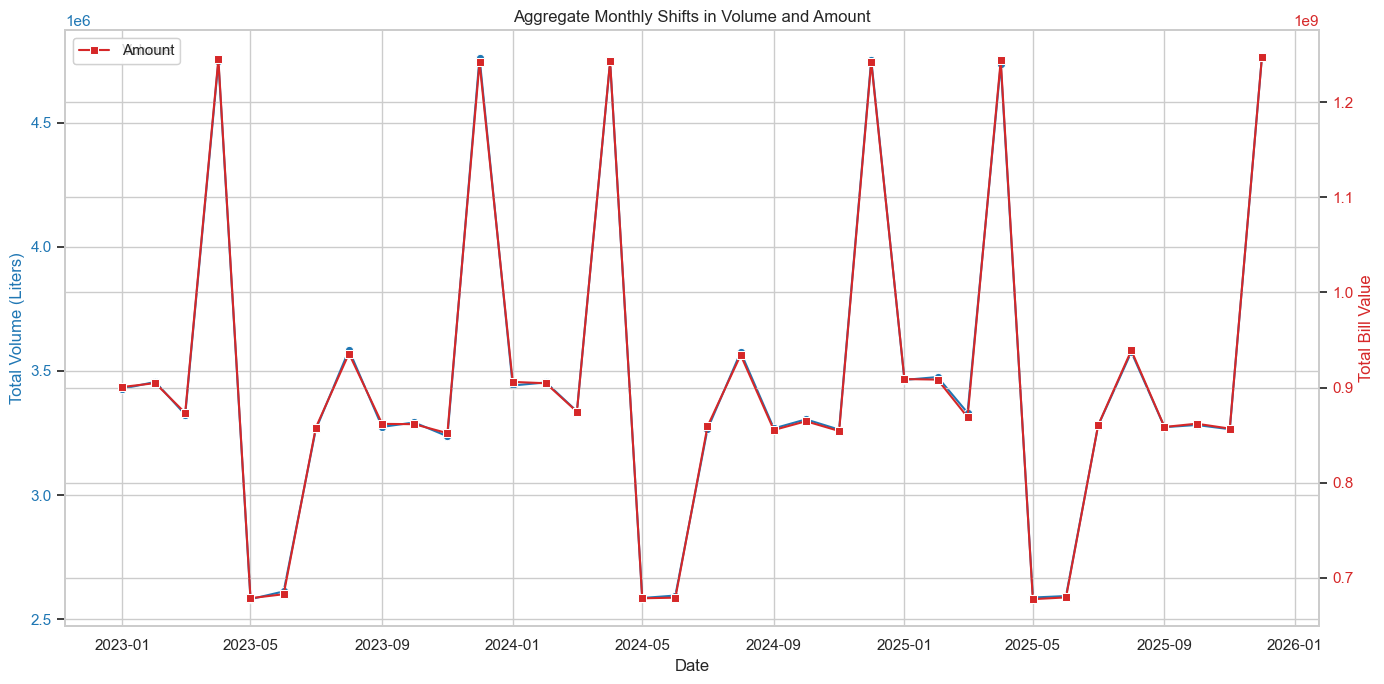

In [11]:
# Prepare time-series data
df_trans['Date'] = pd.to_datetime(df_trans[['Year', 'Month']].assign(day=1))
ts_data = df_trans.groupby('Date')[['Volume_Liters', 'Total_Bill_Value']].sum().reset_index()
ts_data = ts_data.sort_values('Date')

fig, ax1 = plt.subplots(figsize=(14, 7))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Volume (Liters)', color=color)
sns.lineplot(data=ts_data, x='Date', y='Volume_Liters', ax=ax1, color=color, marker='o', label='Volume')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Total Bill Value', color=color)
sns.lineplot(data=ts_data, x='Date', y='Total_Bill_Value', ax=ax2, color=color, marker='s', label='Amount')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Aggregate Monthly Shifts in Volume and Amount')
fig.tight_layout()
plt.show()

## 5. Division (Province) Time-Series Trends
Overlayed trends for each division (Province).

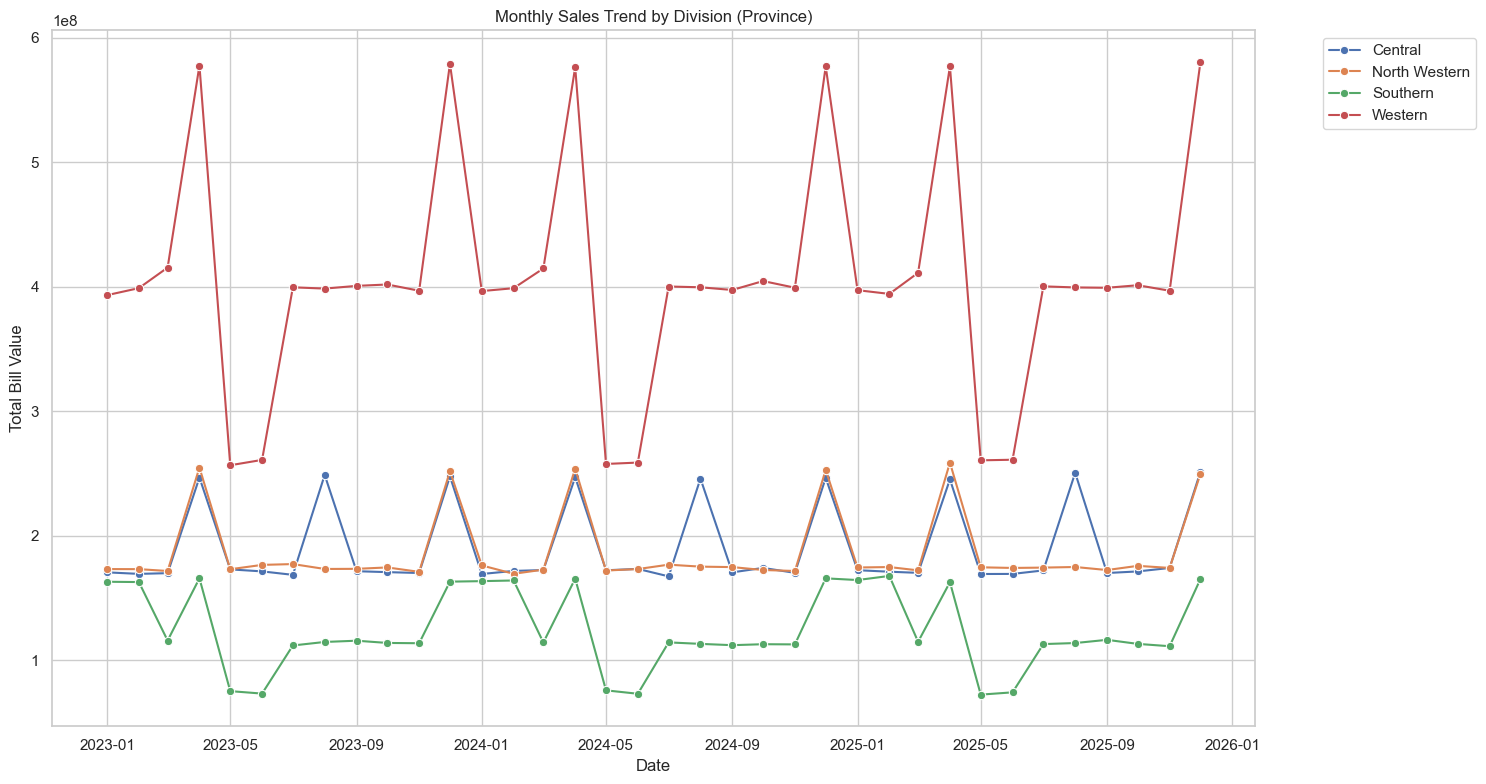

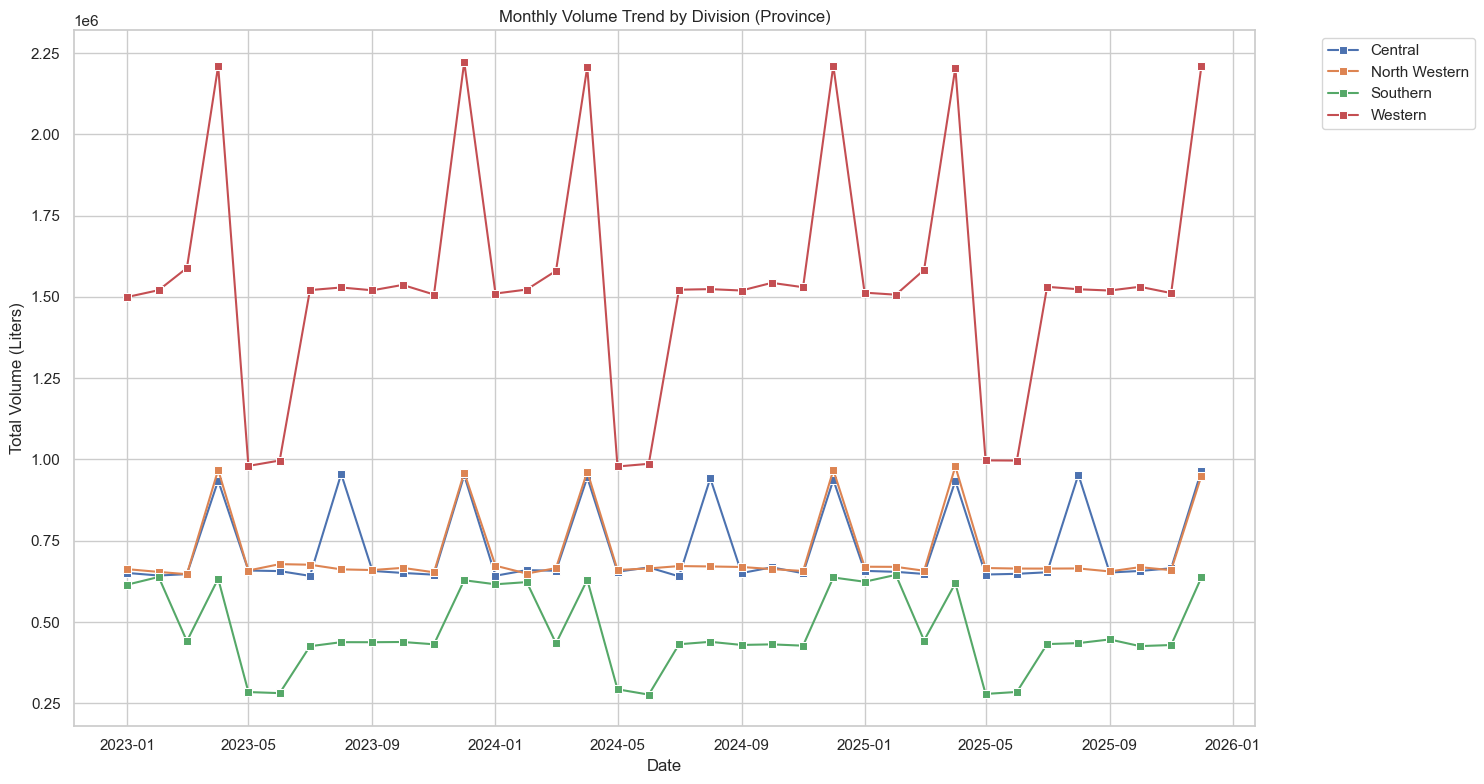

In [12]:
# Province mapping logic
province_map = {
    'W': 'Western', 'C': 'Central', 'S': 'Southern', 'NW': 'North Western',
    'E': 'Eastern', 'NC': 'North Central', 'U': 'Uva', 'SG': 'Sabaragamuwa', 'N': 'Northern'
}

def extract_province(dist_id):
    parts = dist_id.split('_')
    return province_map.get(parts[1], 'Other') if len(parts) > 1 else 'Unknown'

df_trans['Province'] = df_trans['Distributor_ID'].apply(extract_province)

# Grouping data
prov_trends = df_trans.groupby(['Date', 'Province'])[['Total_Bill_Value', 'Volume_Liters']].sum().reset_index()

plt.figure(figsize=(15, 8))
sns.lineplot(data=prov_trends, x='Date', y='Total_Bill_Value', hue='Province', marker='o')
plt.title('Monthly Sales Trend by Division (Province)')
plt.ylabel('Total Bill Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
sns.lineplot(data=prov_trends, x='Date', y='Volume_Liters', hue='Province', marker='s')
plt.title('Monthly Volume Trend by Division (Province)')
plt.ylabel('Total Volume (Liters)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

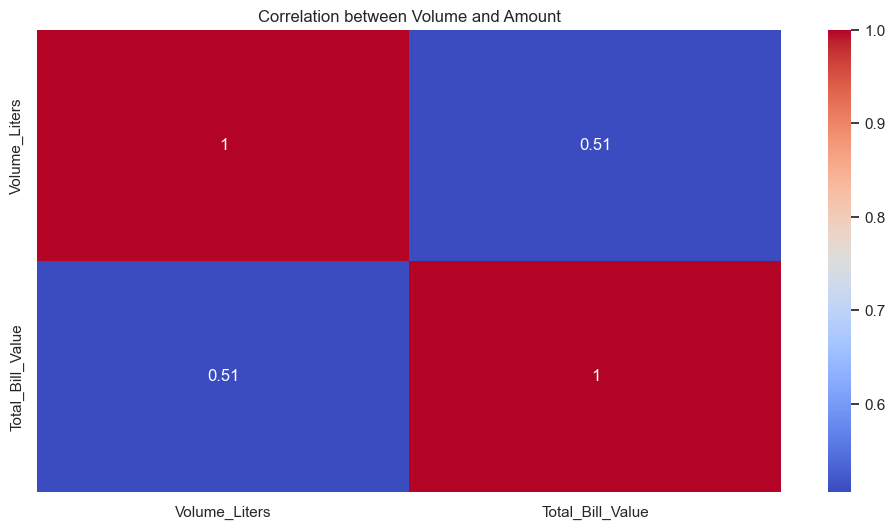

In [13]:
corr = df_trans[['Volume_Liters', 'Total_Bill_Value']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation between Volume and Amount')
plt.show()